In [1]:
import numpy as np
import matplotlib.pyplot as  plt

# Preparing Input Data 

In [2]:
def generate_linear(n=100):   
    import numpy as np
    pts = np.random.uniform(0, 1, (n, 2)  )  # 隨機生成 n 個點，每個點有兩個特徵
    inputs = []
    labels = []     
    for pt in   pts :
        inputs.append([pt[0], pt[1]])
        distance = (pt[0] - pt[1]) / 1.414
        if pt[0] > pt[1]:
            labels.append(0)
        else:
            labels.append(1)
    return np.array(inputs), np.array(labels).reshape(n, 1)

inputs, labels = generate_linear()


#print("Inputs: {} , Labels: {}\n".format(inputs, labels))
print(inputs.shape)
print(labels.shape)
        

(100, 2)
(100, 1)


In [3]:
def generate_XOR_easy():
   # import numpy as np
    inputs = []
    labels = []
    for i in range(11):
        inputs.append([0.1 * i, 0.1 * i])
        labels.append(0)
        if 0.1 * i == 0.5:
            continue
        inputs.append([0.1 * i, 1 - 0.1 * i])
        labels.append(1)
    return np.array(inputs), np.array(labels).reshape(21, 1)

inputs, labels = generate_XOR_easy()
print(inputs.shape)
print(labels.shape)

(21, 2)
(21, 1)


# Activation function

In [4]:
def Sigmoid(x):
    return 1/ (1.0+np.exp(-x))
def Derivative_Sigmoid(x): 
    return x * (1 - x)

In [5]:
def ReLu(x):
    return np.where(x>0,x,0)
def Derivative_ReLu(x):
    return np.where(x>0,1,0)

In [6]:
def tanh(x):
    return np.tanh(x)
def  Derivative_tanh(x):
    return 1 - np.multiply(x, x)

# Some utility


In [6]:
def show_result(x, y, pred_y):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(14, 7))
    #plotting the ground truth
    plt.subplot(1,2,1,aspect='equal')
    plt.title('Ground truth', fontsize=18)
    for i in range(x.shape[0]):
        if y[i] == 0:
            plt.plot(x[i][0], x[i][1], 'ro') #red 0
        else:
            plt.plot(x[i][0], x[i][1], 'bo') #blue 1

    #plotting predicting
    plt.subplot(1,2,2,aspect='equal')
    plt.text(0, 0, f'Accuracy: {sum(pred_y == y)/y.size}', fontsize = 16, 
         bbox = dict(facecolor = 'white', alpha = 0.5))
    plt.title('Predict result', fontsize=18)
    for i in range(x.shape[0]):
        if pred_y[i] == 0:
            plt.plot(x[i][0], x[i][1], 'ro')
        else:
            plt.plot(x[i][0], x[i][1], 'bo')

In [7]:
def show_result_compare(x, y, predlr1_y,predlr2_y,label1,label2):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(14, 7))
    #plotting the ground truth
    plt.subplot(1,3,1,aspect='equal')
    plt.title('Ground truth', fontsize=18)
    for i in range(x.shape[0]):
        if y[i] == 0:
            plt.plot(x[i][0], x[i][1], 'ro') #red 0
        else:
            plt.plot(x[i][0], x[i][1], 'bo') #blue 1

    #plotting predicting
    plt.subplot(1,3,2,aspect='equal')
    plt.text(0, 0, f'Accuracy: {sum(predlr1_y == y)/y.size}', fontsize = 16, 
         bbox = dict(facecolor = 'white', alpha = 0.5))
    plt.title(label1, fontsize=18)
    for i in range(x.shape[0]):
        if predlr1_y[i] == 0:
            plt.plot(x[i][0], x[i][1], 'ro')
        else:
            plt.plot(x[i][0], x[i][1], 'bo')
            
    #plotting predicting
    plt.subplot(1,3,3,aspect='equal')
    plt.text(0, 0, f'Accuracy: {sum(predlr2_y == y)/y.size}', fontsize = 16, 
         bbox = dict(facecolor = 'white', alpha = 0.5))
    plt.title(label2, fontsize=18)
    for i in range(x.shape[0]):
        if predlr2_y[i] == 0:
            plt.plot(x[i][0], x[i][1], 'ro')
        else:
            plt.plot(x[i][0], x[i][1], 'bo')

In [8]:
def show(x,y,model):
    print("--------- Training -----------")
    loss_list = []
    epoch_list = []

    plt.title("Learning Curve")
    for epoch in range(1, epochs + 1):
        y_test = model.forward(x)
        loss = model.back_propagation(x, y)
        
        if( (epoch) % 10000 == 0):
            print(f"epoch: {epoch} loss: {loss}")
        #每100更新loss
        if( epoch % 100 == 0):
            loss_list.append(loss)
            epoch_list.append(epoch)
            
    plt.plot(epoch_list, loss_list)
    plt.ylabel('loss', fontsize = 14)
    plt.xlabel('epochs', fontsize = 14)

    # testing
    print("------------- Testing ------------")
    y_pred_probability = model.forward(x)
    print(y_pred_probability)
    # >0.5 -> label 1 <0.5 ->label 0
    y_pred = np.where(y_pred_probability > 0.5, 1, 0)

    print("------------Iteration---------------")

    for i in range(y_pred_probability.size) :
        print(f"Iter:{i+1} |      Ground truth : {y[i]} |   prediction : {y_pred_probability[i]}")
        

    print("---------accuracy----------------------")
    print("accuracy: ", sum(1 for i, j in zip(y, y_pred) if i == j) / len(y) * 100 ,"%")
    
    print("----------Graph-----------------------------")
    show_result(x,y,y_pred)


In [9]:
def compare(x,y,mode1,model2,label1,label2):
    print(f"--------- {label1} Training -----------")
    loss_list = []
    epoch_list = []

    plt.title("Learning Curve")
    for epoch in range(1, epochs + 1):
        y_test = model1.forward(x)
        loss = model1.back_propagation(x, y)
        
        if(epoch % 1000 == 0):
            print(f"epoch: {epoch} loss: {loss}")
        #每100更新loss
        if(epoch % 100 == 0):
            loss_list.append(loss)
            epoch_list.append(epoch)
            
    plt.plot(epoch_list, loss_list, label=label1)
    plt.ylabel('loss', fontsize = 14)
    plt.xlabel('epochs', fontsize = 14)

    # testing
    print(f"-------------{label1} Testing ------------")
    y_pred_probability = model1.forward(x)
    print(y_pred_probability)
    # >0.5 -> label 1 <0.5 ->label 0
    y_pred1 = np.where(y_pred_probability > 0.5, 1, 0)

    print(f"------------{label1} Iteration---------------")

    for i in range(y_pred_probability.size) :
        print(f"Iter:{i+1} |      Ground truth : {y[i]} |   prediction : {y_pred_probability[i]}")
        

    print("---------accuracy----------------------")
    print("accuracy: ", sum(1 for i, j in zip(y, y_pred1) if i == j) / len(y) * 100 ,"%")




    #############################################################################


    # training
    print(f"--------- {label2} Training -----------")
    loss_list = []
    epoch_list = []

    plt.title("Learning Curve")
    for epoch in range(1, epochs + 1):
        y_test = model2.forward(x)
        loss = model2.back_propagation(x, y)
        
        if(epoch % 1000 == 0):
            print(f"epoch: {epoch} loss: {loss}")
        #每100更新loss
        if(epoch % 100 == 0):
            loss_list.append(loss)
            epoch_list.append(epoch)
            


    # testing
    print(f"------------- {label2}Testing ------------")
    y_pred_probability = model2.forward(x)
    print(y_pred_probability)
    # >0.5 -> label 1 <0.5 ->label 0
    y_pred2 = np.where(y_pred_probability > 0.5, 1, 0)

    print(f"------------{label2} Iteration---------------")

    for i in range(y_pred_probability.size) :
        print(f"Iter:{i+1} |      Ground truth : {y[i]} |   prediction : {y_pred_probability[i]}")
        

    print("---------accuracy----------------------")
    print("accuracy: ", sum(1 for i, j in zip(y, y_pred2) if i == j) / len(y) * 100 ,"%")

    print("---------------LR curve---------------")
    plt.plot(epoch_list, loss_list , label=label2)
    plt.legend()
    plt.show()
    
    show_result_compare(x,y,y_pred1,y_pred2,label1,label2)

# Model

In [10]:
class Model:
    def __init__ (self,input_size=2,hidden1_size=10,hidden2_size=10,output_size=1,
                  learning_rate = 0.1 ,activate = "Sigmoid", optimizer="SGD",decay=0.9):
        # init
        self.input_size = input_size
        self.hidden1_size = hidden1_size
        self.hidden2_size = hidden2_size
        self.output_size = output_size
        self.activate = activate
        self.learning_rate = learning_rate
        self.optimizer = optimizer
        
        #weight bias setting
        self.W1 = np.random.randn(input_size,hidden1_size)
        self.W2 = np.random.randn(hidden1_size,hidden2_size)
        self.W3 = np.random.randn(hidden2_size,output_size)
        
        self.y=()
        
        self.b1 = np.random.randn(1,hidden1_size)/100
        self.b2 = np.random.randn(1,hidden2_size)/100
        self.b3 = np.random.randn(1,output_size)/100
        
        # Define hyperparameters for Momentum optimizer
        self.v_W1 = 0  # Velocity for W1
        self.v_W2 = 0  # Velocity for W2
        self.v_W3 = 0  # Velocity for W3
        self.v_b1 = 0  # Velocity for b1
        self.v_b2 = 0  # Velocity for b2
        self.v_b3 = 0  # Velocity for b3
        self.decay =decay
        
    def forward(self , x)    :
        self.x = x
        #first layer
        
        self.hidden1 = np.dot(x,self.W1) + self.b1
        
        if(self.activate == "Sigmoid") :
            self.hidden1 = Sigmoid(self.hidden1)
        elif(self.activate == "ReLu") :
            self.hidden1 = ReLu(self.hidden1)
        elif(self.activate == "tanh") :
            self.hidden1 = tanh(self.hidden1)
        elif self.activate == "None":
            pass
       
        
        #second layer
        self.hidden2 = np.dot(self.hidden1,self.W2) + self.b2
        
        if(self.activate == "Sigmoid") :
            self.hidden2 = Sigmoid(self.hidden2)
        elif(self.activate == "ReLu") :
            self.hidden2 = ReLu(self.hidden2)
        elif(self.activate == "tanh") :
            self.hidden2 = tanh(self.hidden2)
        elif self.activate == "None":
            pass
        
        
        #output layer
        
        self.y = np.dot(self.hidden2,self.W3) + self.b3
        
        if(self.activate == "Sigmoid") :
            self.y = Sigmoid(self.y)
        elif(self.activate == "ReLu") :
            self.y = ReLu(self.y)
        elif(self.activate == "tanh") :
           self.y = tanh(self.y)
        elif self.activate == "None":
            pass
       
        return self.y
    
    def clip_gradients(self, grad, threshold=1.0):
        grad = np.clip(grad, -threshold, threshold)
        return grad

    def back_propagation(self,x,y_gt):
        #update w3 b3
        y_error =(self.y - y_gt) 
        # error 乘 activation function的導數
        # 算gradient
        if(self.activate == "Sigmoid") :
            grad = y_error * Derivative_Sigmoid(self.y)
        elif(self.activate == "ReLu") :
            grad = y_error * Derivative_ReLu(self.y)
        elif(self.activate == "tanh") :
            grad = y_error * Derivative_tanh(self.y)
        elif self.activate == "None":
            grad=y_error
            
        grad = self.clip_gradients(grad)
            
        if(self.optimizer == "SGD"):
            #update
            self.W3 -= self.learning_rate * np.dot(self.hidden2.T,grad)
            self.b3 -= self.learning_rate * np.sum(grad,axis=0)
        elif(self.optimizer == "Momentum"):
            self.v_W3 = self.decay *self.v_W3 + self.learning_rate * np.dot(self.hidden2.T,grad)
            self.v_b3 =self.decay *self.v_b3 + self.learning_rate * np.sum(grad,axis=0)
            self.W3 -= self.v_W3
            self.b3 -= self.b3
            
            #update w2 b2
        hidden2_error = np.dot(grad,self.W3.T)
        if(self.activate == "Sigmoid") :
            grad = hidden2_error * Derivative_Sigmoid(self.hidden2)
        elif(self.activate == "ReLu") :
            grad = hidden2_error * Derivative_ReLu(self.hidden2)
        elif(self.activate == "tanh") :
            grad = hidden2_error * Derivative_tanh(self.hidden2)
        elif self.activate == "None":
            grad=hidden2_error
            
        grad = self.clip_gradients(grad)
            
        #update
        if(self.optimizer == "SGD"):
            self.W2 -= self.learning_rate * np.dot(self.hidden1.T,grad)
            self.b2 -= self.learning_rate * np.sum(grad,axis=0)
        elif(self.optimizer == "Momentum"):
            self.v_W2 = self.decay *self.v_W2 + self.learning_rate * np.dot(self.hidden1.T,grad)
            self.v_b2 =self.decay *self.v_b2 + self.learning_rate * np.sum(grad,axis=0)
            self.W2 -= self.v_W2
            self.b2 -= self.b2
        #update w1 b1
        hidden1_error = np.dot(grad,self.W2.T)
        if(self.activate == "Sigmoid") :
            grad = hidden1_error * Derivative_Sigmoid(self.hidden1)
        elif(self.activate == "ReLu") :
            grad = hidden1_error * Derivative_ReLu(self.hidden1)
        elif(self.activate == "tanh") :
            grad = hidden1_error* Derivative_tanh(self.hidden1)
        elif self.activate == "None":
            grad = hidden1_error
            
        grad = self.clip_gradients(grad)
            
        #update
        if(self.optimizer == "SGD"):
            self.W1 -= self.learning_rate * np.dot(x.T,grad)
            self.b1 -= self.learning_rate * np.sum(grad,axis=0)
        elif(self.optimizer == "Momentum"):
            self.v_W1 = self.decay *self.v_W1 + self.learning_rate * np.dot(x.T,grad)
            self.v_b1 =self.decay *self.v_b1 + self.learning_rate * np.sum(grad,axis=0)
            self.W1 -= self.v_W1
            self.b1 -= self.b1
        
        return  np.sum ((self.y-y_gt) ** 2)/self.y.shape[0]  
    
        
            

# Train 

## Linear Data

--------- Training -----------
epoch: 10000 loss: 0.0001003926041716694
epoch: 20000 loss: 3.6007967464966466e-05
epoch: 30000 loss: 2.049456461213936e-05
epoch: 40000 loss: 1.3927213026789106e-05
epoch: 50000 loss: 1.0390139177806662e-05
epoch: 60000 loss: 8.209559608530463e-06
epoch: 70000 loss: 6.743455046575347e-06
epoch: 80000 loss: 5.696310842264765e-06
epoch: 90000 loss: 4.914338643239946e-06
epoch: 100000 loss: 4.31008132311798e-06
------------- Testing ------------
[[3.75110381e-08]
 [3.68588328e-08]
 [7.90418556e-06]
 [2.08215855e-08]
 [9.99999999e-01]
 [9.99999996e-01]
 [9.99894192e-01]
 [1.87584698e-08]
 [9.99999915e-01]
 [9.99999999e-01]
 [9.99999998e-01]
 [1.15070735e-06]
 [9.99999998e-01]
 [2.66478001e-08]
 [1.04329403e-02]
 [9.99999998e-01]
 [4.01170734e-08]
 [2.33291181e-08]
 [9.99999999e-01]
 [9.99999999e-01]
 [3.70036108e-08]
 [2.36711179e-08]
 [9.99999999e-01]
 [1.90757772e-08]
 [9.99999998e-01]
 [9.99999884e-01]
 [9.99999998e-01]
 [9.99999997e-01]
 [2.64376032e-05]

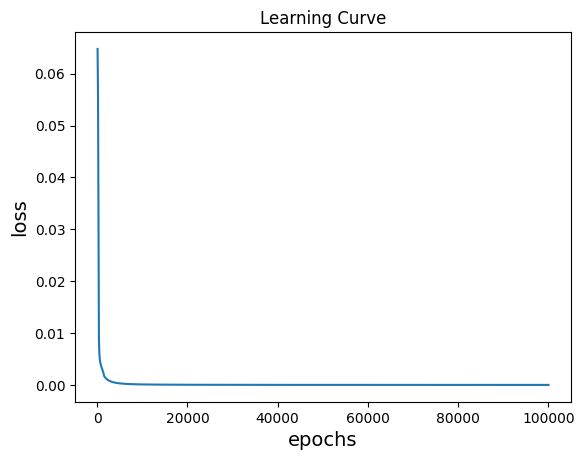

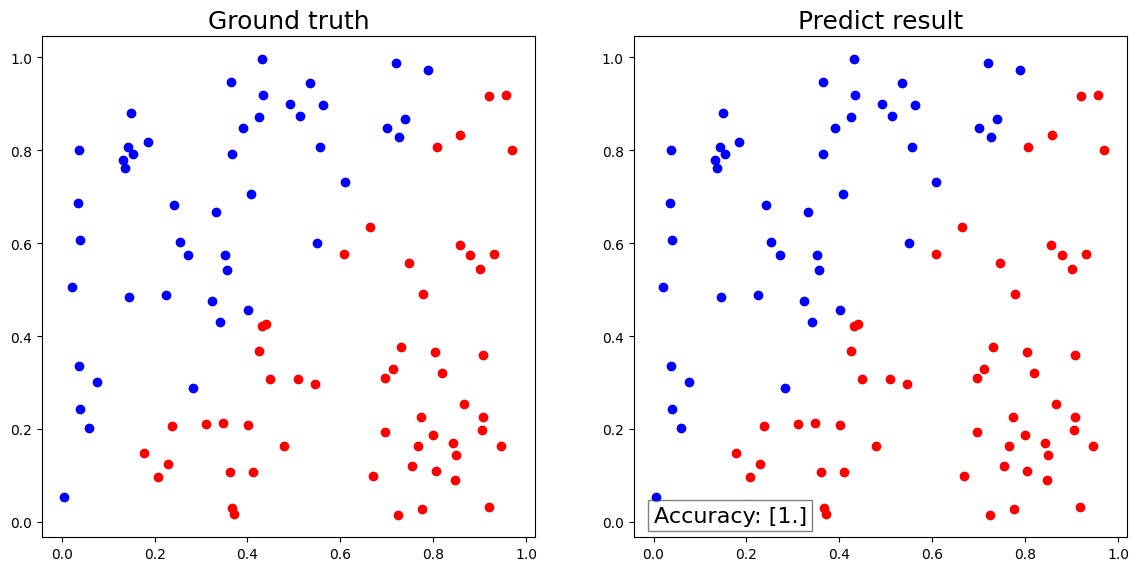

In [36]:
x,y =generate_linear()
epochs = 100000
model = Model()
# training
show(x,y,model)


## XOR data

--------- Training -----------
epoch: 10000 loss: 0.00022564345316235956
epoch: 20000 loss: 7.885819183337981e-05
epoch: 30000 loss: 4.525848566079785e-05
epoch: 40000 loss: 3.104766030181322e-05
epoch: 50000 loss: 2.3352859978479785e-05
epoch: 60000 loss: 1.8579642174358777e-05
epoch: 70000 loss: 1.535138721068204e-05
epoch: 80000 loss: 1.3033199921949401e-05
epoch: 90000 loss: 1.1293622411352801e-05
epoch: 100000 loss: 9.943486594328285e-06
------------- Testing ------------
[[9.12066657e-04]
 [9.99999283e-01]
 [1.76733484e-04]
 [9.99999115e-01]
 [1.05458612e-04]
 [9.99998531e-01]
 [3.45159353e-04]
 [9.99992531e-01]
 [3.37631151e-03]
 [9.92024055e-01]
 [8.78365435e-03]
 [3.42273114e-03]
 [9.93399357e-01]
 [5.90010983e-04]
 [9.99990269e-01]
 [1.00795412e-04]
 [9.99988470e-01]
 [2.28789288e-05]
 [9.99967652e-01]
 [7.14014837e-06]
 [9.99923646e-01]]
------------Iteration---------------
Iter:1 |      Ground truth : [0] |   prediction : [0.00091207]
Iter:2 |      Ground truth : [1] |   pr

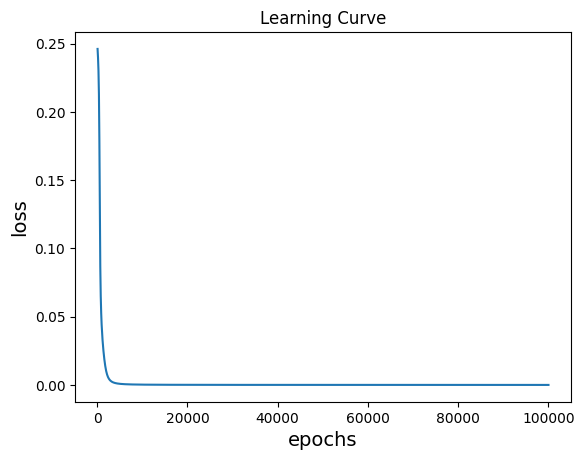

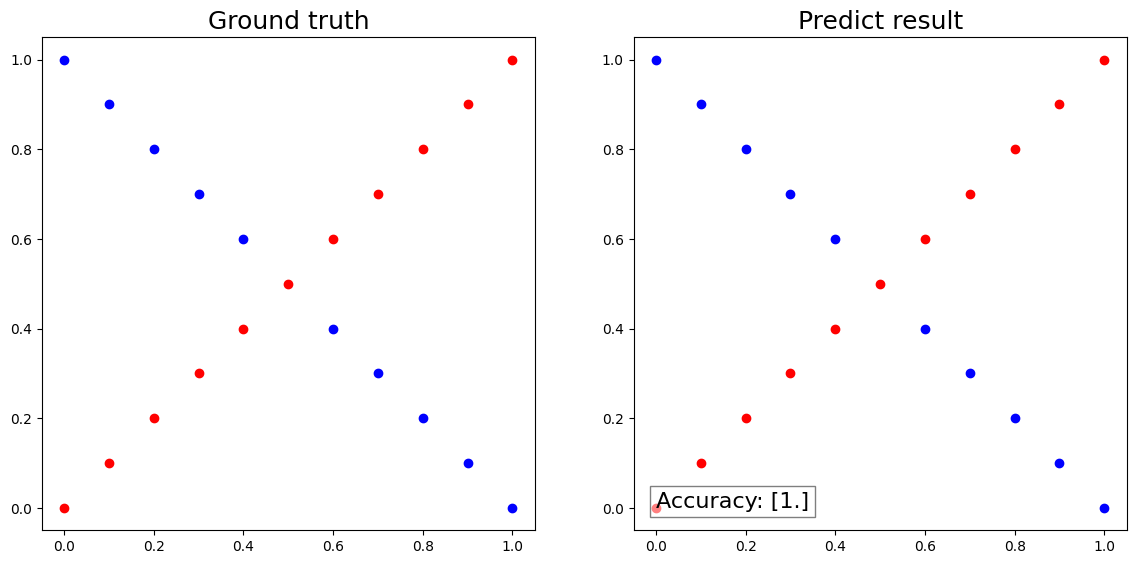

In [37]:
X_xor,Y_xor =generate_XOR_easy()

epochs = 100000
model = Model()
# training
show(X_xor,Y_xor,model)

# Discussion

## Differnet LR

### Linear Data

--------- lr=0.001 Training -----------
epoch: 1000 loss: 0.11954129850329924
epoch: 2000 loss: 0.07297371105258517
epoch: 3000 loss: 0.054401341477975436
epoch: 4000 loss: 0.04391180602227639
epoch: 5000 loss: 0.03694835207408117
-------------lr=0.001 Testing ------------
[[0.00649326]
 [0.84573154]
 [0.74363513]
 [0.01128735]
 [0.13876125]
 [0.62627651]
 [0.99216205]
 [0.63820976]
 [0.74231326]
 [0.98680194]
 [0.97075065]
 [0.00836386]
 [0.31598057]
 [0.2913779 ]
 [0.69872901]
 [0.38969104]
 [0.99346434]
 [0.02563119]
 [0.02724692]
 [0.00719646]
 [0.06019759]
 [0.01309609]
 [0.0877336 ]
 [0.28491234]
 [0.10944044]
 [0.53135951]
 [0.08562039]
 [0.82439924]
 [0.72750964]
 [0.07632579]
 [0.99375817]
 [0.09185233]
 [0.35736922]
 [0.02448043]
 [0.55846032]
 [0.2465822 ]
 [0.02585405]
 [0.04966251]
 [0.8970347 ]
 [0.01050127]
 [0.99696709]
 [0.99109264]
 [0.01183802]
 [0.74790459]
 [0.33827257]
 [0.80472931]
 [0.93911483]
 [0.99393124]
 [0.97789964]
 [0.9795618 ]
 [0.99181966]
 [0.98741762

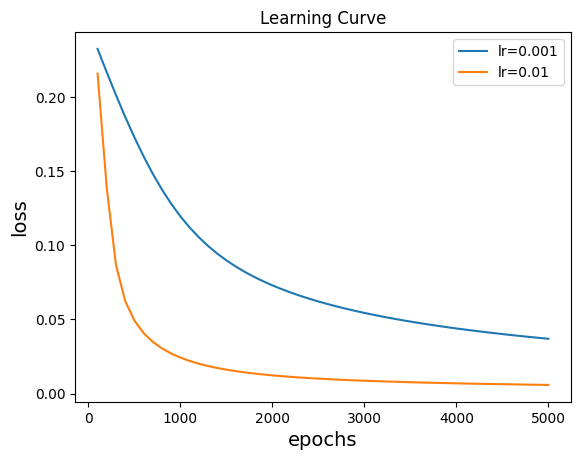

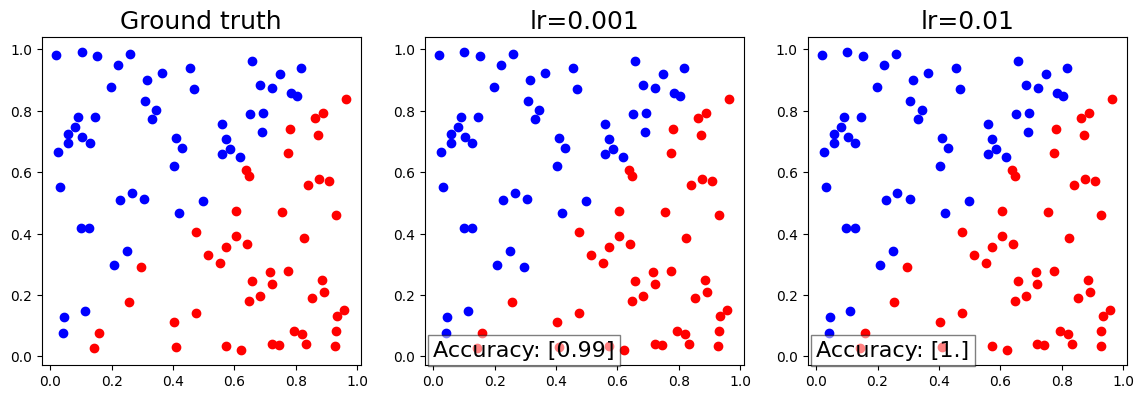

In [22]:
x,y =generate_linear()
epochs = 5000
model1  = Model(learning_rate=0.001)
model2 = Model(learning_rate=0.01)
# training

compare(x,y,model1,model2,"lr=0.001","lr=0.01")



### XOR Data

--------- lr=0.001 Training -----------
epoch: 1000 loss: 0.24766285180862885
epoch: 2000 loss: 0.2461809754152574
epoch: 3000 loss: 0.24474816201422378
epoch: 4000 loss: 0.24334648827350366
epoch: 5000 loss: 0.2419627248520466
epoch: 6000 loss: 0.24058709212860485
epoch: 7000 loss: 0.23921209549287362
epoch: 8000 loss: 0.23783148963313888
epoch: 9000 loss: 0.236439496901318
epoch: 10000 loss: 0.235030380282706
-------------lr=0.001 Testing ------------
[[0.33783063]
 [0.4087722 ]
 [0.37422102]
 [0.42049314]
 [0.41033755]
 [0.43394765]
 [0.44255083]
 [0.44938499]
 [0.46831245]
 [0.46699127]
 [0.48680031]
 [0.49859037]
 [0.50858782]
 [0.50495567]
 [0.53179526]
 [0.50730685]
 [0.55554703]
 [0.50689836]
 [0.57879448]
 [0.50472781]
 [0.60054291]]
------------lr=0.001 Iteration---------------
Iter:1 |      Ground truth : [0] |   prediction : [0.33783063]
Iter:2 |      Ground truth : [1] |   prediction : [0.4087722]
Iter:3 |      Ground truth : [0] |   prediction : [0.37422102]
Iter:4 |     

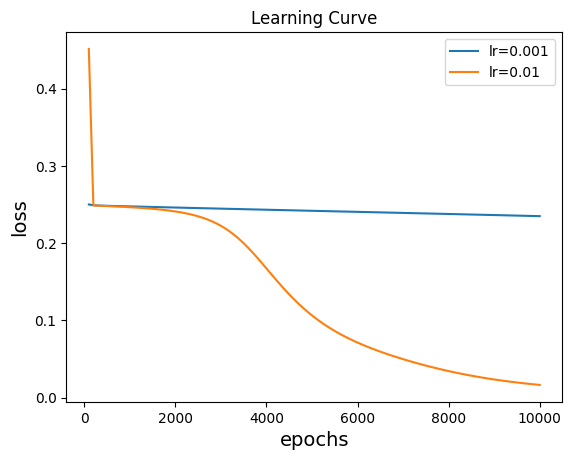

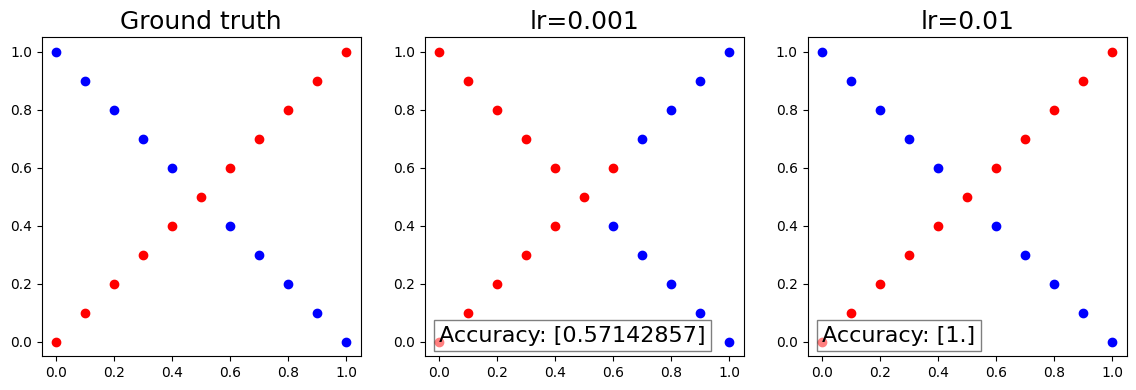

In [26]:
x_xor,y_xor =generate_XOR_easy()
epochs = 10000
model1  = Model(learning_rate=0.001)
model2 = Model(learning_rate=0.01)
# training
compare(x_xor,y_xor,model1,model2,"lr=0.001","lr=0.01")


## Different hidden layer (2 vs 4)

In [13]:
class Model_4layer:
    def __init__(self, input_size=2, hidden1_size=10, hidden2_size=10, hidden3_size=10, hidden4_size=10, 
                 output_size=1, learning_rate=0.1, activate="Sigmoid"):
        # init
        self.input_size = input_size
        self.hidden1_size = hidden1_size
        self.hidden2_size = hidden2_size
        self.hidden3_size = hidden3_size
        self.hidden4_size = hidden4_size
        self.output_size = output_size
        self.activate = activate
        self.learning_rate = learning_rate
        
        # weight and bias initialization
        self.W1 = np.random.randn(input_size, hidden1_size)
        self.W2 = np.random.randn(hidden1_size, hidden2_size)
        self.W3 = np.random.randn(hidden2_size, hidden3_size)
        self.W4 = np.random.randn(hidden3_size, hidden4_size)
        self.W5 = np.random.randn(hidden4_size, output_size)
        
        self.b1 = np.random.randn(1, hidden1_size) / 100
        self.b2 = np.random.randn(1, hidden2_size) / 100
        self.b3 = np.random.randn(1, hidden3_size) / 100
        self.b4 = np.random.randn(1, hidden4_size) / 100
        self.b5 = np.random.randn(1, output_size) / 100
    
    def forward(self, x):
        self.x = x
        
        # First hidden layer
        self.hidden1 = np.dot(x, self.W1) + self.b1
        if self.activate == "Sigmoid":
            self.hidden1 = Sigmoid(self.hidden1)
        elif self.activate == "ReLu":
            self.hidden1 = ReLu(self.hidden1)
        elif self.activate == "tanh":
            self.hidden1 = tanh(self.hidden1)
        
        # Second hidden layer
        self.hidden2 = np.dot(self.hidden1, self.W2) + self.b2
        if self.activate == "Sigmoid":
            self.hidden2 = Sigmoid(self.hidden2)
        elif self.activate == "ReLu":
            self.hidden2 = ReLu(self.hidden2)
        elif self.activate == "tanh":
            self.hidden2 = tanh(self.hidden2)
        
        # Third hidden layer
        self.hidden3 = np.dot(self.hidden2, self.W3) + self.b3
        if self.activate == "Sigmoid":
            self.hidden3 = Sigmoid(self.hidden3)
        elif self.activate == "ReLu":
            self.hidden3 = ReLu(self.hidden3)
        elif self.activate == "tanh":
            self.hidden3 = tanh(self.hidden3)
        
        # Fourth hidden layer
        self.hidden4 = np.dot(self.hidden3, self.W4) + self.b4
        if self.activate == "Sigmoid":
            self.hidden4 = Sigmoid(self.hidden4)
        elif self.activate == "ReLu":
            self.hidden4 = ReLu(self.hidden4)
        elif self.activate == "tanh":
            self.hidden4 = tanh(self.hidden4)
        
        # Output layer
        self.y = np.dot(self.hidden4, self.W5) + self.b5
        if self.activate == "Sigmoid":
            self.y = Sigmoid(self.y)
        elif self.activate == "ReLu":
            self.y = ReLu(self.y)
        elif self.activate == "tanh":
            self.y = tanh(self.y)
        
        return self.y
    
    def clip_gradients(self, grad, threshold=1.0):
        grad = np.clip(grad, -threshold, threshold)
        return grad
    
    def back_propagation(self, x, y_gt):
        # Update W5 and b5
        y_error = (self.y - y_gt)
        if self.activate == "Sigmoid":
            grad = y_error * Derivative_Sigmoid(self.y)
        elif self.activate == "ReLu":
            grad = y_error * Derivative_ReLu(self.y)
        elif self.activate == "tanh":
            grad = y_error * Derivative_tanh(self.y)
        grad = self.clip_gradients(grad)
        
        self.W5 -= self.learning_rate * np.dot(self.hidden4.T, grad)
        self.b5 -= self.learning_rate * np.sum(grad, axis=0)
        
        # Update W4 and b4
        hidden4_error = np.dot(grad, self.W5.T)
        if self.activate == "Sigmoid":
            grad = hidden4_error * Derivative_Sigmoid(self.hidden4)
        elif self.activate == "ReLu":
            grad = hidden4_error * Derivative_ReLu(self.hidden4)
        elif self.activate == "tanh":
            grad = hidden4_error * Derivative_tanh(self.hidden4)
        grad = self.clip_gradients(grad)
        
        self.W4 -= self.learning_rate * np.dot(self.hidden3.T, grad)
        self.b4 -= self.learning_rate * np.sum(grad, axis=0)
        
        # Update W3 and b3
        hidden3_error = np.dot(grad, self.W4.T)
        if self.activate == "Sigmoid":
            grad = hidden3_error * Derivative_Sigmoid(self.hidden3)
        elif self.activate == "ReLu":
            grad = hidden3_error * Derivative_ReLu(self.hidden3)
        elif self.activate == "tanh":
            grad = hidden3_error * Derivative_tanh(self.hidden3)
        grad = self.clip_gradients(grad)
        
        self.W3 -= self.learning_rate * np.dot(self.hidden2.T, grad)
        self.b3 -= self.learning_rate * np.sum(grad, axis=0)
        
        # Update W2 and b2
        hidden2_error = np.dot(grad, self.W3.T)
        if self.activate == "Sigmoid":
            grad = hidden2_error * Derivative_Sigmoid(self.hidden2)
        elif self.activate == "ReLu":
            grad = hidden2_error * Derivative_ReLu(self.hidden2)
        elif self.activate == "tanh":
            grad = hidden2_error * Derivative_tanh(self.hidden2)
        grad = self.clip_gradients(grad)
        
        self.W2 -= self.learning_rate * np.dot(self.hidden1.T, grad)
        self.b2 -= self.learning_rate * np.sum(grad, axis=0)
        
        # Update W1 and b1
        hidden1_error = np.dot(grad, self.W2.T)
        if self.activate == "Sigmoid":
            grad = hidden1_error * Derivative_Sigmoid(self.hidden1)
        elif self.activate == "ReLu":
            grad = hidden1_error * Derivative_ReLu(self.hidden1)
        elif self.activate == "tanh":
            grad = hidden1_error * Derivative_tanh(self.hidden1)
        grad = self.clip_gradients(grad)
        
        self.W1 -= self.learning_rate * np.dot(x.T, grad)
        self.b1 -= self.learning_rate * np.sum(grad, axis=0)
    
        return np.sum((self.y - y_gt) ** 2) / self.y.shape[0]

### Linear

--------- 2-layer Training -----------
epoch: 1000 loss: 0.22481995322339907
epoch: 2000 loss: 0.21186876697687473
epoch: 3000 loss: 0.20029921075418347
epoch: 4000 loss: 0.18905124407031748
epoch: 5000 loss: 0.17853821364520392
epoch: 6000 loss: 0.16877960242047332
epoch: 7000 loss: 0.1596258330924255
epoch: 8000 loss: 0.15093879246175393
epoch: 9000 loss: 0.14264537253598658
epoch: 10000 loss: 0.13472684486619413
epoch: 11000 loss: 0.12719416892075686
epoch: 12000 loss: 0.12006795926165047
epoch: 13000 loss: 0.11336638723835955
epoch: 14000 loss: 0.1070994566199699
epoch: 15000 loss: 0.10126737629080079
epoch: 16000 loss: 0.09586121010883784
epoch: 17000 loss: 0.09086459162876491
epoch: 18000 loss: 0.08625577175739593
epoch: 19000 loss: 0.08200959171350236
epoch: 20000 loss: 0.07809917853915918
-------------2-layer Testing ------------
[[0.31656182]
 [0.27904387]
 [0.62092241]
 [0.67714072]
 [0.31215828]
 [0.52739993]
 [0.88111159]
 [0.3813921 ]
 [0.60080272]
 [0.88814262]
 [0.275434

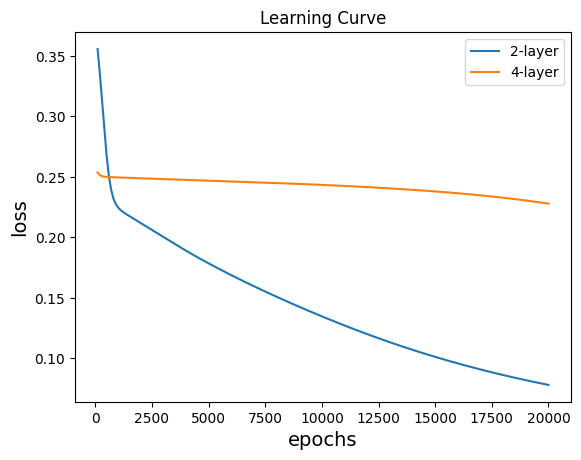

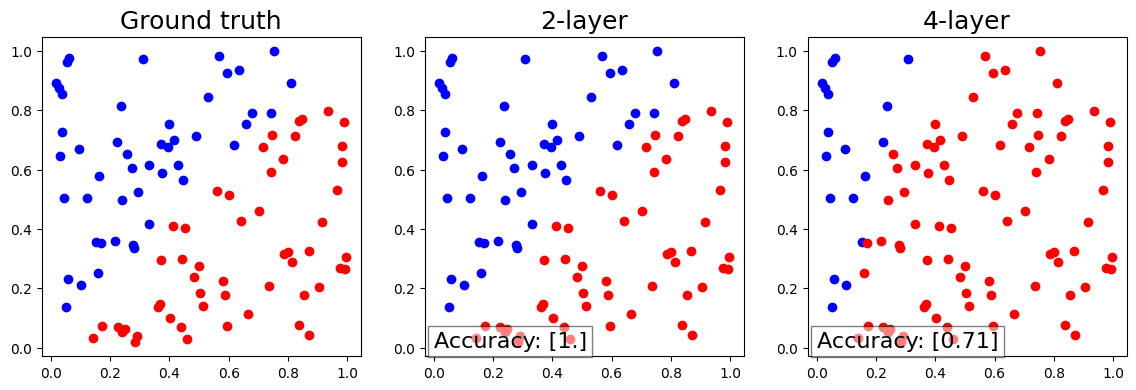

In [16]:
x,y =generate_linear()
epochs = 20000
model1  = Model(learning_rate=1e-4)
model2 = Model_4layer(learning_rate=1e-4)

compare(x,y,model1,model2,"2-layer","4-layer")

### XOR Data

--------- 2-layer Training -----------
epoch: 1000 loss: 0.24549776249849758
epoch: 2000 loss: 0.2415913174077889
epoch: 3000 loss: 0.23390479105203388
epoch: 4000 loss: 0.21874754048179482
epoch: 5000 loss: 0.18833097298101675
epoch: 6000 loss: 0.1393052301198596
epoch: 7000 loss: 0.0972875490611263
epoch: 8000 loss: 0.07160324565740887
-------------2-layer Testing ------------
[[0.06491888]
 [0.93182024]
 [0.10184943]
 [0.9277519 ]
 [0.16358397]
 [0.89898163]
 [0.23730964]
 [0.77405364]
 [0.29072771]
 [0.45696645]
 [0.3062714 ]
 [0.29012359]
 [0.43774218]
 [0.25698702]
 [0.71150204]
 [0.21950856]
 [0.87853192]
 [0.18509675]
 [0.93753157]
 [0.15658702]
 [0.95852076]]
------------2-layer Iteration---------------
Iter:1 |      Ground truth : [0] |   prediction : [0.06491888]
Iter:2 |      Ground truth : [1] |   prediction : [0.93182024]
Iter:3 |      Ground truth : [0] |   prediction : [0.10184943]
Iter:4 |      Ground truth : [1] |   prediction : [0.9277519]
Iter:5 |      Ground truth 

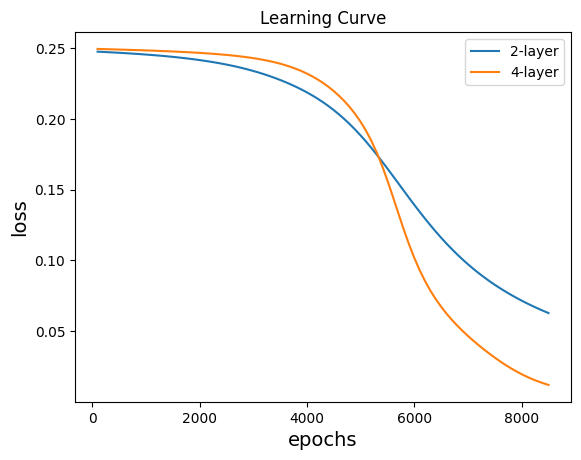

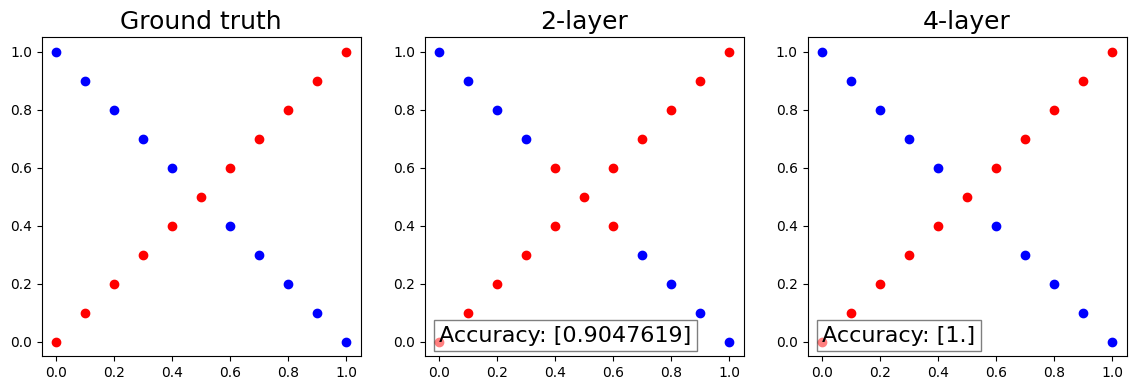

In [21]:
x_xor,y_xor =generate_XOR_easy()
epochs = 8500
model1  = Model(learning_rate=1e-2)
model2 = Model_4layer(learning_rate=1e-2)

compare(x_xor,y_xor,model1,model2,"2-layer","4-layer")

## No activate function

### Linear Data

--------- activate Training -----------
epoch: 1000 loss: 0.24939126105061152
epoch: 2000 loss: 0.2423371573884948
epoch: 3000 loss: 0.2351611366960123
epoch: 4000 loss: 0.22768542269326672
epoch: 5000 loss: 0.21980972485250455
epoch: 6000 loss: 0.21149216844247673
epoch: 7000 loss: 0.20274183042054417
epoch: 8000 loss: 0.19360899423679986
epoch: 9000 loss: 0.18417770401641015
epoch: 10000 loss: 0.17456033882806637
epoch: 11000 loss: 0.16489051572351257
epoch: 12000 loss: 0.15531217245007414
epoch: 13000 loss: 0.1459662405802063
epoch: 14000 loss: 0.13697808710975168
epoch: 15000 loss: 0.12844831815208899
epoch: 16000 loss: 0.12044806379840862
epoch: 17000 loss: 0.11301859110966095
epoch: 18000 loss: 0.10617428362562792
epoch: 19000 loss: 0.09990766074985417
epoch: 20000 loss: 0.09419513798684033
epoch: 21000 loss: 0.08900253180504385
epoch: 22000 loss: 0.08428971922634655
epoch: 23000 loss: 0.08001422624839966
epoch: 24000 loss: 0.07613376963749413
epoch: 25000 loss: 0.072607909051893

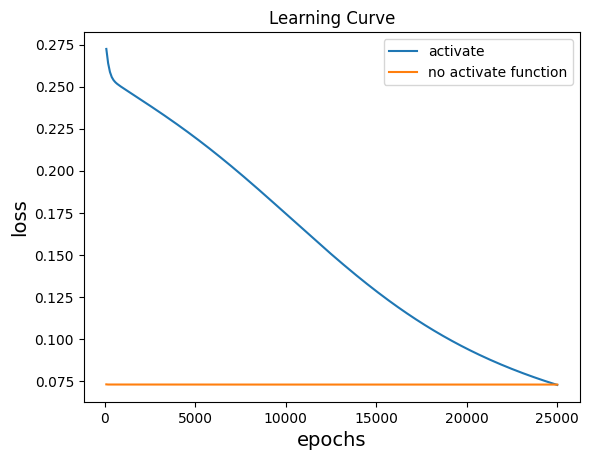

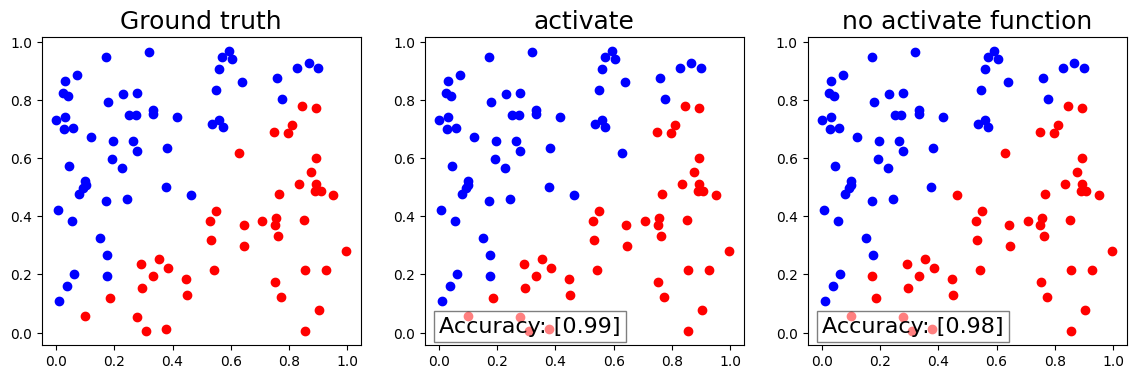

In [68]:
x,y =generate_linear()
epochs = 25000
model1 =Model(learning_rate= 1e-4)
model2 = Model(activate="None",learning_rate= 1e-4 )
# training
compare(x,y,model1,model2,"activate","no activate function")

### XOR Data

--------- activate Training -----------
epoch: 1000 loss: 0.050365794180878144
epoch: 2000 loss: 0.009267179031621988
epoch: 3000 loss: 0.0024262223598399465
epoch: 4000 loss: 0.0011066550927171456
epoch: 5000 loss: 0.0006589014053322098
epoch: 6000 loss: 0.00045077374642649257
epoch: 7000 loss: 0.0003349972916427424
epoch: 8000 loss: 0.0002628386661546929
epoch: 9000 loss: 0.00021422512747361233
epoch: 10000 loss: 0.0001795739326254812
-------------activate Testing ------------
[[6.18652548e-03]
 [9.99996995e-01]
 [4.15518854e-03]
 [9.99996348e-01]
 [4.23979694e-03]
 [9.99994101e-01]
 [6.90723521e-03]
 [9.99966686e-01]
 [1.64204840e-02]
 [9.68453695e-01]
 [2.86697710e-02]
 [2.25229943e-02]
 [9.69251815e-01]
 [9.82707939e-03]
 [9.99959112e-01]
 [3.39897568e-03]
 [9.99989262e-01]
 [1.17531864e-03]
 [9.99991553e-01]
 [4.51845984e-04]
 [9.99992035e-01]]
------------activate Iteration---------------
Iter:1 |      Ground truth : [0] |   prediction : [0.00618653]
Iter:2 |      Ground truth :

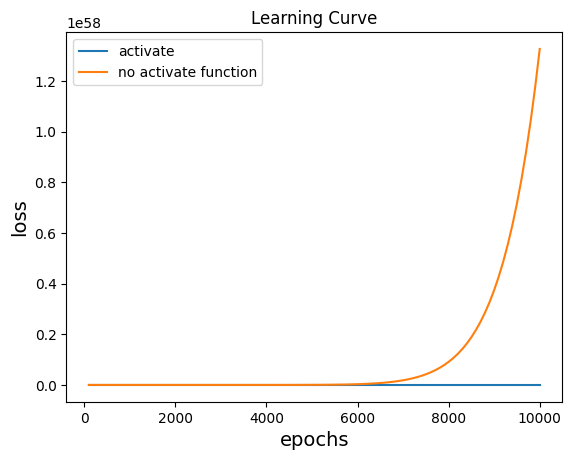

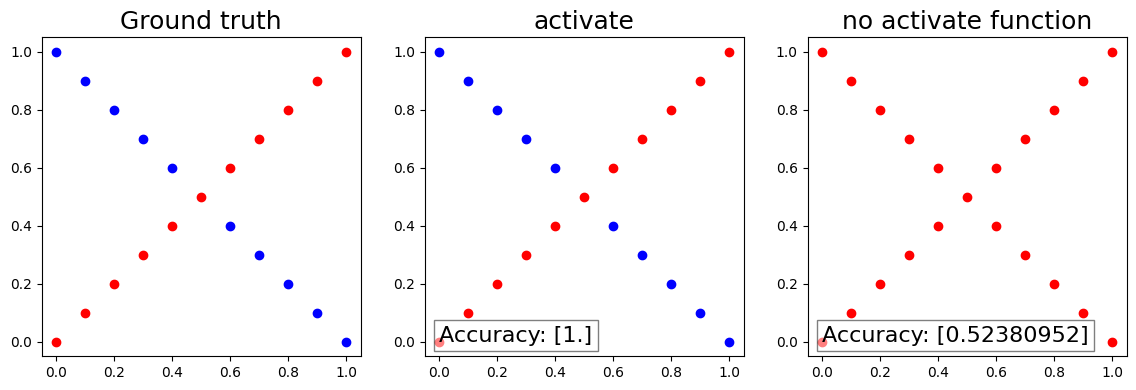

In [70]:
x_xor,y_xor =generate_XOR_easy()

epochs = 10000

model1 =Model( learning_rate= 1e-1)
model2 = Model(activate="None",learning_rate= 1e-1)
# training
compare(x_xor,y_xor,model1,model2,"activate","no activate function")

## Different hidden unit (5 vs 10)

### Linear Data

--------- 5 hidden unit Training -----------
epoch: 1000 loss: 0.2446135381905544
epoch: 2000 loss: 0.23982312473326917
epoch: 3000 loss: 0.23788651121047943
epoch: 4000 loss: 0.23573889818887722
epoch: 5000 loss: 0.2333237008280985
epoch: 6000 loss: 0.2306041162191819
epoch: 7000 loss: 0.22754986837320004
epoch: 8000 loss: 0.2241412977678247
epoch: 9000 loss: 0.2203719198706898
epoch: 10000 loss: 0.2162476723343091
-------------5 hidden unit Testing ------------
[[0.50124611]
 [0.57405787]
 [0.48838406]
 [0.46764161]
 [0.59418583]
 [0.5943001 ]
 [0.53664543]
 [0.44396423]
 [0.43821774]
 [0.43487947]
 [0.56007457]
 [0.51336249]
 [0.5241176 ]
 [0.573161  ]
 [0.46243192]
 [0.46346891]
 [0.59137317]
 [0.58294554]
 [0.52454267]
 [0.46922559]
 [0.43613126]
 [0.53193353]
 [0.50324483]
 [0.47064395]
 [0.48570996]
 [0.58005933]
 [0.49930103]
 [0.57826207]
 [0.52356884]
 [0.45446355]
 [0.47836857]
 [0.53212482]
 [0.56265907]
 [0.45976756]
 [0.56590522]
 [0.50333808]
 [0.53954662]
 [0.5427985 ]


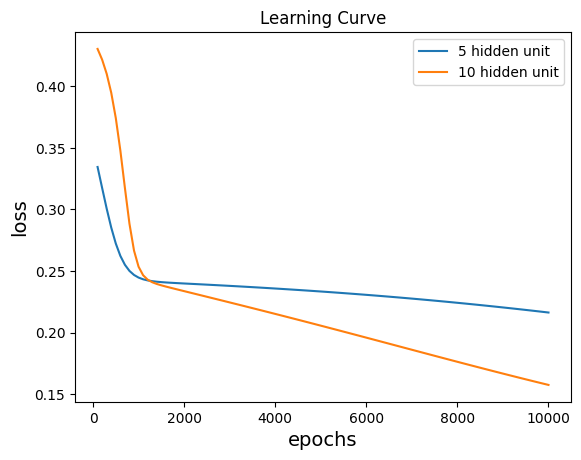

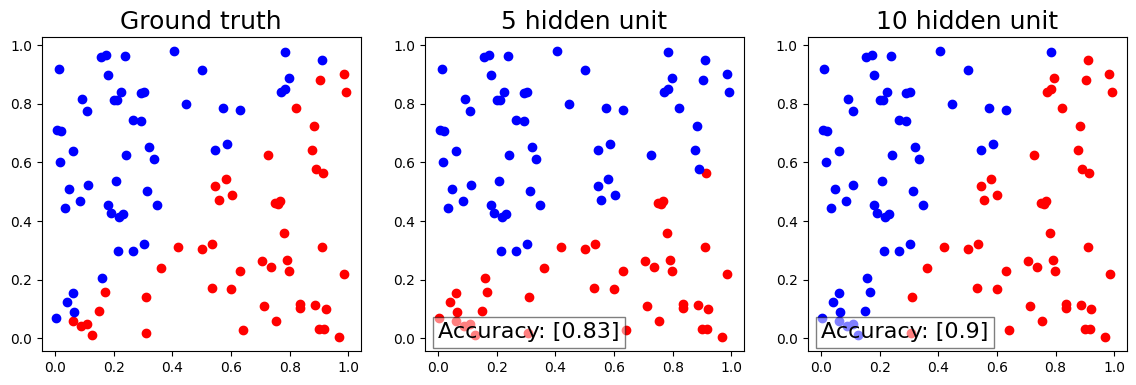

In [34]:
x,y =generate_linear()
epochs = 10000
model1 =Model(hidden1_size= 5,hidden2_size= 5,learning_rate= 1e-4)
model2 = Model(hidden1_size= 10,hidden2_size= 10,learning_rate= 1e-4 )
# training
compare(x,y,model1,model2,"5 hidden unit","10 hidden unit")

### XOR Data

--------- 5 hidden unit Training -----------
epoch: 1000 loss: 0.24647075342412722
epoch: 2000 loss: 0.24355798875009643
epoch: 3000 loss: 0.23828197057583422
epoch: 4000 loss: 0.22829090827117585
epoch: 5000 loss: 0.2092302247819085
epoch: 6000 loss: 0.17174447617128016
epoch: 7000 loss: 0.11858377545355434
epoch: 8000 loss: 0.08232051351550981
epoch: 9000 loss: 0.06254573454329403
epoch: 10000 loss: 0.05050398259129346
-------------5 hidden unit Testing ------------
[[0.03436298]
 [0.96993366]
 [0.04768999]
 [0.96692016]
 [0.09508529]
 [0.94490166]
 [0.20430715]
 [0.82757931]
 [0.31797124]
 [0.50062632]
 [0.34570296]
 [0.29781942]
 [0.48714981]
 [0.22386034]
 [0.77609877]
 [0.15815265]
 [0.93038681]
 [0.11103593]
 [0.9741575 ]
 [0.08002611]
 [0.98689688]]
------------5 hidden unit Iteration---------------
Iter:1 |      Ground truth : [0] |   prediction : [0.03436298]
Iter:2 |      Ground truth : [1] |   prediction : [0.96993366]
Iter:3 |      Ground truth : [0] |   prediction : [0.04

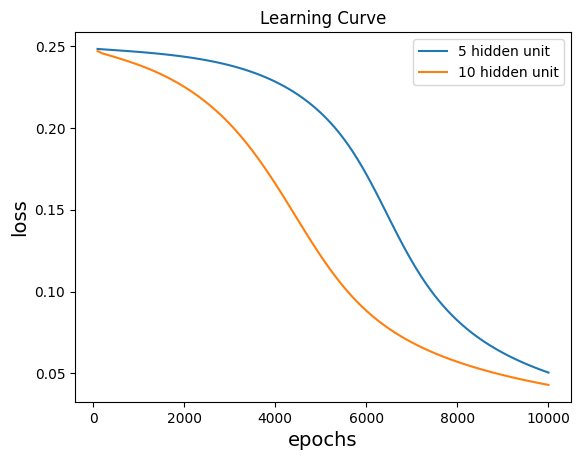

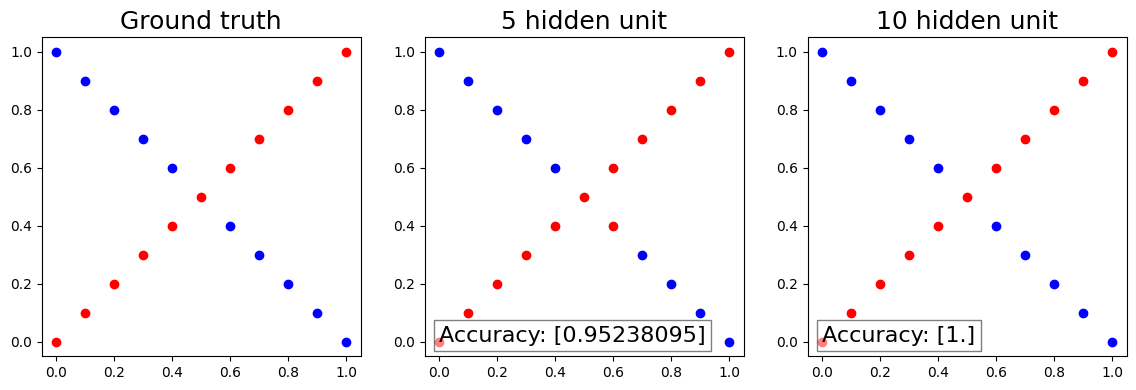

In [12]:
x_xor,y_xor =generate_XOR_easy()

epochs = 10000

model1 =Model( hidden1_size= 5,hidden2_size=5,learning_rate= 1e-2)
model2 = Model(hidden1_size= 10,hidden2_size=10,learning_rate= 1e-2)
# training
compare(x_xor,y_xor,model1,model2,"5 hidden unit","10 hidden unit")

# Extra

## Different activation function

### Linear Data

--------- Training -----------
epoch: 10000 loss: 0.003949595093528373
epoch: 20000 loss: 0.0016710697024806354
epoch: 30000 loss: 0.0012173282189352017
epoch: 40000 loss: 0.000645321384611727
epoch: 50000 loss: 0.00021642275430931637
------------- Testing ------------
[[1.00430026]
 [0.95818838]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.99198262]
 [0.99766944]
 [1.01473271]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.98039643]
 [0.9932402 ]
 [0.99667823]
 [0.        ]
 [0.        ]
 [0.9921225 ]
 [0.        ]
 [0.        ]
 [1.00193794]
 [0.        ]
 [0.97948624]
 [0.        ]
 [1.0005302 ]
 [0.99957969]
 [0.        ]
 [1.02294018]
 [1.01651112]
 [0.979898  ]
 [0.96989961]
 [0.        ]
 [0.        ]
 [0.98109515]
 [0.        ]
 [0.        ]
 [0.98532658]
 [0.        ]
 [0.        ]
 [1.02241462]
 [0.        ]
 [1.01626399]
 [0.        ]
 [0.98916531]
 [0.        ]
 [0.        ]
 [0.98728725]
 [0.        ]
 [

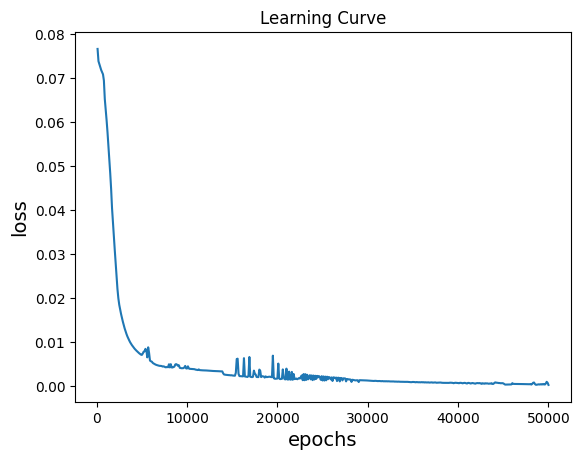

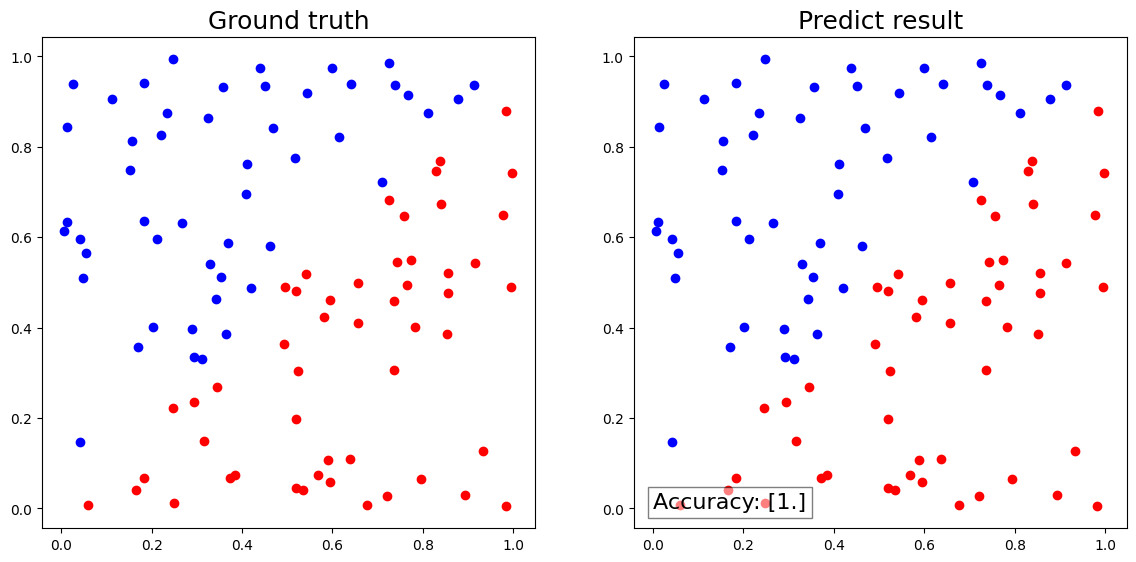

In [54]:
x,y =generate_linear()
epochs = 50000
model = Model(activate= "ReLu" ,learning_rate=1e-3)
# training
#compare(x,y,model1,model2,"Sigmoid","ReLu")
show(x,y,model)

### XOR Data

--------- Training -----------
epoch: 10000 loss: 8.278766503777918e-07
epoch: 20000 loss: 4.5454405338541675e-07
epoch: 30000 loss: 3.182618443835862e-07
epoch: 40000 loss: 2.4104814902540375e-07
epoch: 50000 loss: 1.6914731352933267e-07
------------- Testing ------------
[[0.        ]
 [0.99910746]
 [0.        ]
 [0.99894333]
 [0.        ]
 [0.9987792 ]
 [0.        ]
 [0.99999953]
 [0.        ]
 [0.99958824]
 [0.        ]
 [0.        ]
 [0.99992755]
 [0.        ]
 [0.99990371]
 [0.        ]
 [0.99987986]
 [0.        ]
 [0.99985602]
 [0.        ]
 [0.99983217]]
------------Iteration---------------
Iter:1 |      Ground truth : [0] |   prediction : [0.]
Iter:2 |      Ground truth : [1] |   prediction : [0.99910746]
Iter:3 |      Ground truth : [0] |   prediction : [0.]
Iter:4 |      Ground truth : [1] |   prediction : [0.99894333]
Iter:5 |      Ground truth : [0] |   prediction : [0.]
Iter:6 |      Ground truth : [1] |   prediction : [0.9987792]
Iter:7 |      Ground truth : [0] |   pred

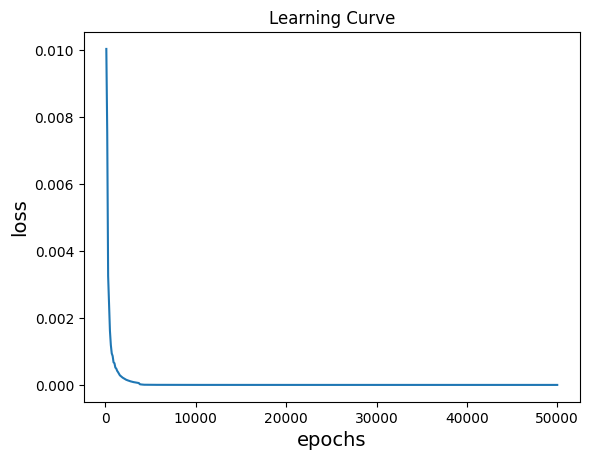

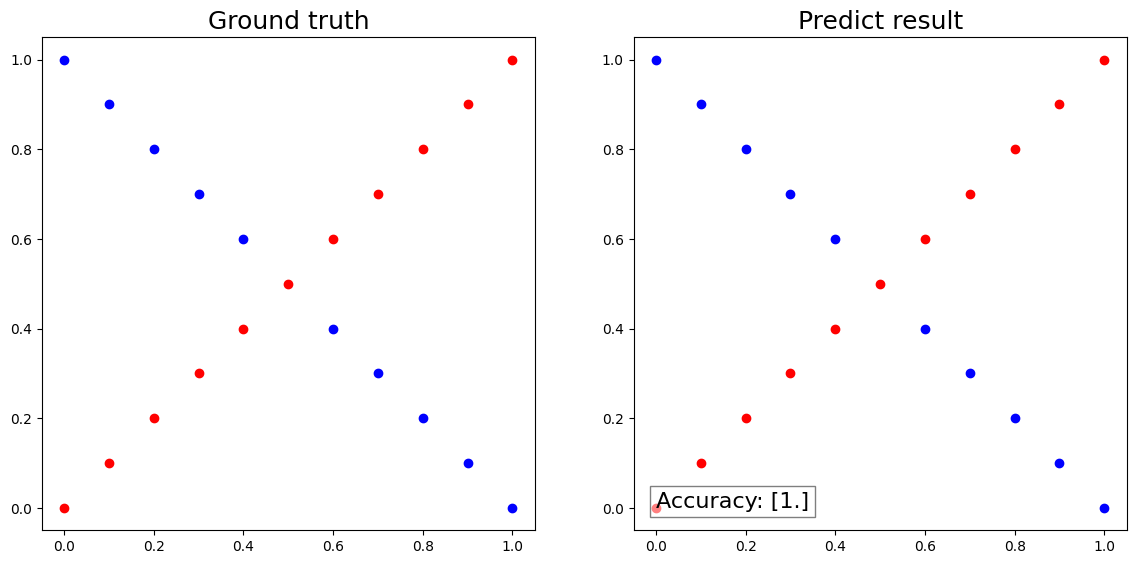

In [56]:
x_xor,y_xor =generate_XOR_easy()
epochs = 50000
model = Model(activate= "ReLu" ,learning_rate=1e-2)
# training
show(x_xor,y_xor,model)

## Convolutional Layers

### Linear Data

--------- Training -----------


ValueError: shapes (1,64) and (1,10) not aligned: 64 (dim 1) != 1 (dim 0)

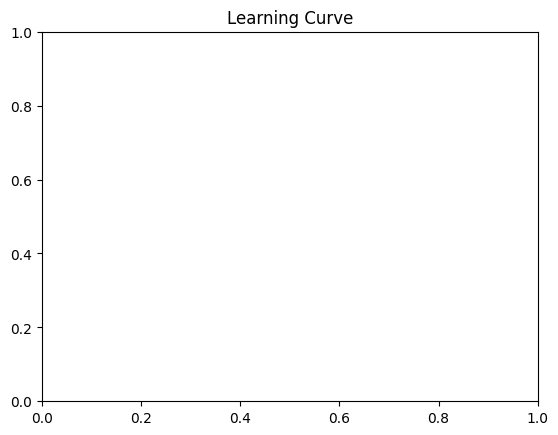

In [61]:
x,y =generate_linear()
epochs = 50000
model =Model_Conv()
show(x,y,model)

## Different Optimizer

### Linear Data

--------- Training -----------


ValueError: cannot reshape array of size 200 into shape (10,10)

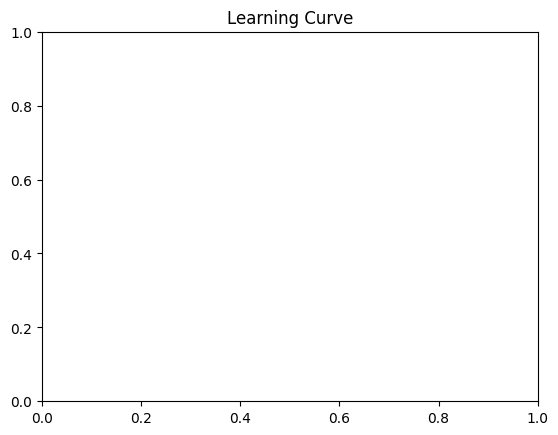

In [64]:
x,y =generate_linear()
epochs = 50000
model =Model(optimizer="Momentum")
show(x,y,model)

### XOR Data

--------- Training -----------
epoch: 10000 loss: 0.00022392114005402504
epoch: 20000 loss: 9.662500148077547e-05
epoch: 30000 loss: 6.068295267733216e-05
epoch: 40000 loss: 4.39546250457904e-05
epoch: 50000 loss: 3.4338192325548305e-05
------------- Testing ------------
[[3.79153587e-04]
 [9.99519264e-01]
 [1.17363665e-03]
 [9.99484552e-01]
 [3.31607913e-03]
 [9.99391834e-01]
 [6.71874682e-03]
 [9.98946541e-01]
 [9.25751583e-03]
 [9.87180654e-01]
 [9.34697916e-03]
 [7.68765175e-03]
 [9.85903008e-01]
 [5.62984963e-03]
 [9.97690827e-01]
 [3.90606779e-03]
 [9.98712667e-01]
 [2.67094801e-03]
 [9.99012553e-01]
 [1.84289364e-03]
 [9.99119746e-01]]
------------Iteration---------------
Iter:1 |      Ground truth : [0] |   prediction : [0.00037915]
Iter:2 |      Ground truth : [1] |   prediction : [0.99951926]
Iter:3 |      Ground truth : [0] |   prediction : [0.00117364]
Iter:4 |      Ground truth : [1] |   prediction : [0.99948455]
Iter:5 |      Ground truth : [0] |   prediction : [0.0033160

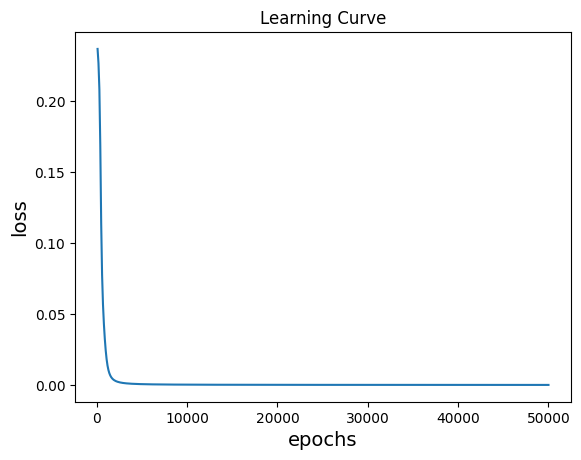

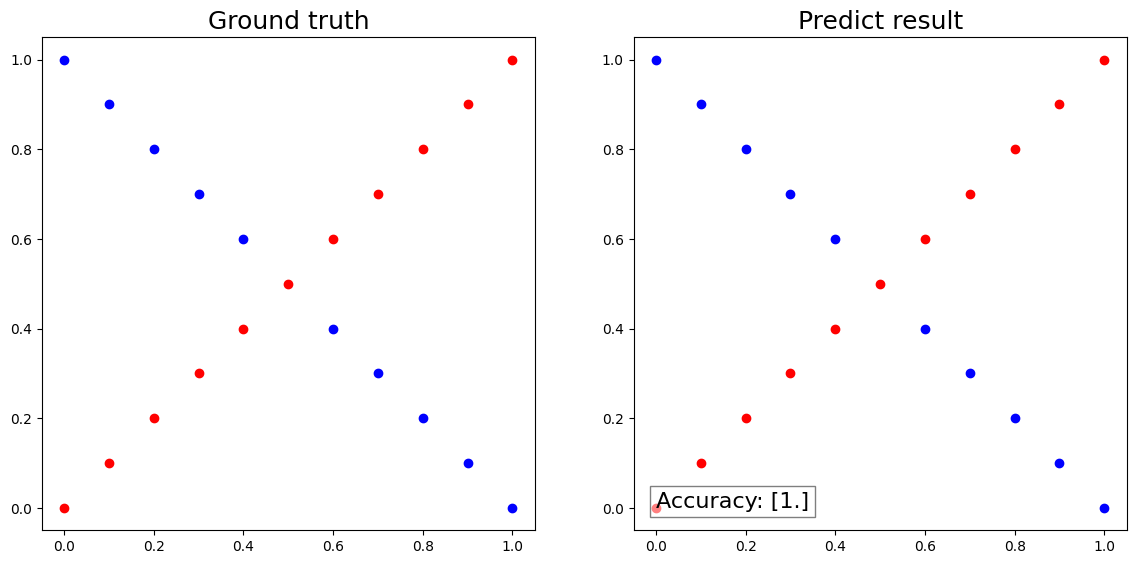

In [45]:
x_xor,y_xor =generate_XOR_easy()
epochs = 50000
model= Model(optimizer="Momentum" ,learning_rate=1e-2)
show(x_xor,y_xor,model)